# Milestone 3: Route, Cancellation, and Seasonal Insights

## Import Libraries

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [7]:
df = pd.read_csv('FInal_Flights_cleaned_data.csv')
df.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,distance,hour,minute,time_hour,name,flight_date,day_of_week,route,cancelled,on_time
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.,2013-01-01,Tuesday,EWR-IAH,0,0.0
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.,2013-01-01,Tuesday,LGA-IAH,0,0.0
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.,2013-01-01,Tuesday,JFK-MIA,0,0.0
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,1576,5,45,2013-01-01 05:00:00,JetBlue Airways,2013-01-01,Tuesday,JFK-BQN,0,1.0
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.,2013-01-01,Tuesday,LGA-ATL,0,1.0


## Week 5: Route and Airport-Level Analysis

### Top 10 Origin-Destination Pairs

In [9]:
od = (
    df.groupby(['origin', 'dest'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)
od

,origin,dest,count
117,JFK,LAX,11262
156,LGA,ATL,10263
204,LGA,ORD,8857
146,JFK,SFO,8204
170,LGA,CLT,6168
55,EWR,ORD,6100
92,JFK,BOS,5898
197,LGA,MIA,5781
120,JFK,MCO,5464
7,EWR,BOS,5327


In [10]:
fig = px.bar(od, x='origin', y='count', color='dest', title='Top 10 Origin-Destination Pairs')
fig.show()

### Delay Heatmaps by Airport and Route

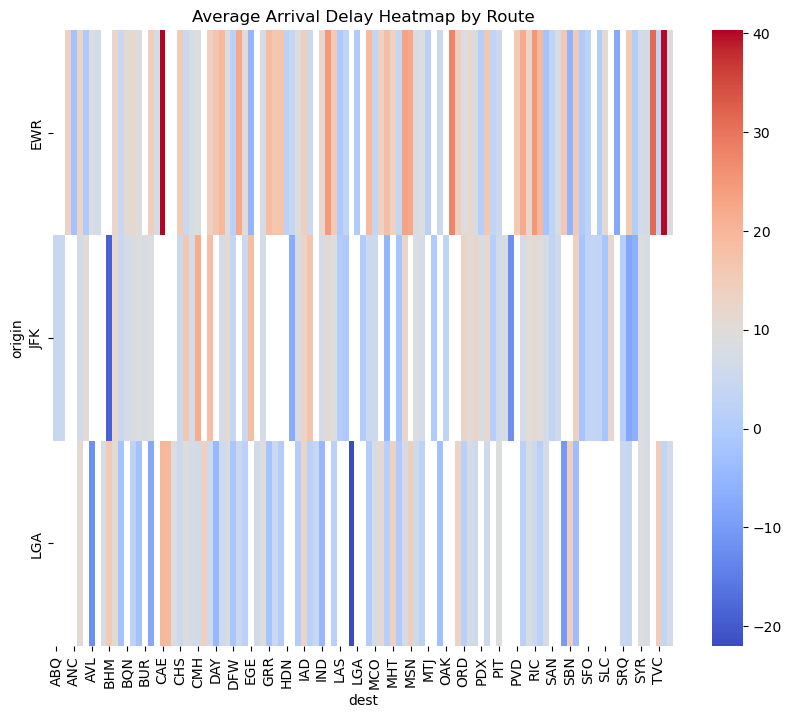

In [11]:
delay = (
    df.groupby(['origin', 'dest'])['arr_delay']
    .mean()
    .reset_index()
)
pivot = delay.pivot(index='origin', columns='dest', values='arr_delay')

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='coolwarm', annot=False)
plt.title('Average Arrival Delay Heatmap by Route')
plt.show()

### Maps showing busiest airports and average delays

In [12]:
# Busiest Airports
busy = df['origin'].value_counts().reset_index()
busy.columns = ['Airport', 'Flight Count']
fig = px.bar(busy.head(10), x='Airport', y='Flight Count', title='Top 10 Busiest Airports')
fig.show()

In [13]:
# Average Delays by Airport
avg_delay = (
    df.groupby('origin')['arr_delay']
    .mean()
    .reset_index()
    .sort_values('arr_delay', ascending=False)
)
fig = px.bar(avg_delay.head(10), x='origin', y='arr_delay', title='Top 10 Airports by Average Arrival Delay')
fig.show()

## Week 6: Seasonal and Cancellation Analysis

### Monthly Cancellation Trends

In [14]:
cancel = df.groupby('month')['cancelled'].sum().reset_index()
fig = px.line(cancel, x='month', y='cancelled', title='Monthly Cancellation Trends')
fig.show()

### Cancellation Types

In [15]:
if 'cancellation_reason' in df.columns:
    cancel_types = df['cancellation_reason'].value_counts().reset_index()
    cancel_types.columns = ['Reason', 'Count']
    fig = px.pie(cancel_types, values='Count', names='Reason', title='Cancellation Types')
    fig.show()
else:
    print('Cancellation reason data not available in this dataset.')

Cancellation reason data not available in this dataset.


### Analyze impact of holidays or winter months

In [16]:
# Winter months: Dec, Jan, Feb
winter = df[df['month'].isin([12, 1, 2])]
winter_cancel_rate = winter['cancelled'].mean()
total_cancel_rate = df['cancelled'].mean()
print(f'Winter cancellation rate: {winter_cancel_rate:.4f}')
print(f'Total cancellation rate: {total_cancel_rate:.4f}')
# Winter months show higher cancellation rates due to weather conditions

Winter cancellation rate: 0.0350
Total cancellation rate: 0.0245
